# FLOW - A Flood Prediction Model Trained on Historical Data

### Step 1 - Select a Data Set
Selected "flood.csv"

### Step 2 - Import Pandas Library

In [1]:
import pandas as pd

### Step 3 - Create a DataFrame variable to read the .csv file
A DataFrame is a 2-Dimensional Data Structure, like a 2-Dimensional Array, or like a table with rows and columns.

In [2]:
df = pd.read_csv("flood.csv")

### Step 4 - Display the rows and columns of the dataset

In [4]:
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


### Step 5 - Display the dataset info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

### Step 6 - Clean and Prepare the Data
The "flood.csv" dataset is already clean, but to clean any dataset in general we would: 
Make columns numeric, handle missing values, and select only useful features (keep all 20 columns and drop the "Flood Probability" Column as it is a target column/variable.

In [6]:
df = df.dropna()   # Removes any rows that contain missing values (NaN) from df.

X = df.drop(columns=["FloodProbability"])   # Creates a new DataFrame 'X' with all columns except 'FloodProbability'.
y = df["FloodProbability"]   # Sets 'FloodProbability' as a target value

### Step 7 - Split Data & Train a Simple Model
Split the Dataset into either a 70/30 pr 80/20 to train and test the model. Training is always the largest part of the split, and testing the smallest.

To Train a model, use a basic 'classifier' like "Random Forest" or "Logistic Regression". A classifier is a type of machine learning model that learns patterns in the data to predict categories (like yes/no or flood/no flood).
 
In other words, a classifier is the tool that "learns" from your data so it can make predictions on new data later.
 
Logistic Regression --> Simple model that tries to draw a straight line (or curve) between the classes.
 
Random Forest --> A Stronger model made up of many decision trees that work together to make predictions.


#### Import the train_test_split function from the Scikit-Learn (sklearn) library

It is used to split your dataset into two (or more) parts:
 - Training Set --> used to teach the model (learn patterns).
 - Testing Set --> used to check how well the model performs on new, unseen data.
 
 This splits your data so that:
 - 80% goes to training (X_train, y_train)
 - 20% goes to testing (X_test, y_test)
 
Explanations:
 - X --> All your input features
 - y --> The output you want to predict (FloodProbability)
 - test_size = 0.2 --> Means 20% of the data is kept for testing, the rest for training.
 - random_state = 42 --> just makes sure the split (80/20) happens the same way every time you run the code.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Step 8 - Pick a model (Regression or Classification)
 
Both types of models can be used but choosing Classification would mean we would recieve a "flood/no flood" type of warning, on the other if we choose the regression model, we can calculate the probability of a flood happening (like 30& chance of flood, etc).
 
We will then choose a Regression Model.

### Step 9 - Train a Regression Model

In [8]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### R2 Score - measures how well predictions fit the trainig data, not if the model will perform well in new undeen conditions.
#### Mean Abdolute Error - tells you how big your prediction errors are (e.g if you're predicting water level (meters) and MAE = 0.3; means the models predictions are 0.3 meters off from real flood levels.

In [9]:
from sklearn.metrics import r2_score, mean_absolute_error

y_prediction = model.predict(X_test)
print("R2 Score: ", r2_score(y_test, y_prediction))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_prediction))

R2 Score:  0.728591585053314
Mean Absolute Error:  0.020492470000000013


### STEP 10 - Add a Simple Alert Rule

In [10]:
def prediction_alert(input_data, threshold=0.3):
    prediction = model.predict([input_data]) [0]
    print(f"Predicted Flood Probability: {prediction:.3f}")

    if prediction >= threshold:
        print("Alert: High Flood Risk.")
    else:
        print("No immediate Risk.")

prediction_alert([
    9, 8, 9, 7,
    9, 8, 9, 7,
    8, 7, 9, 8,
    9, 8, 9, 7,
    9, 8, 9, 7
])

Predicted Flood Probability: 0.641
Alert: High Flood Risk.


/opt/homebrew/Cellar/jupyterlab/4.4.9/libexec/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### STEP 11 - Save the Model and export it as a .pkl so that we can use it for the StreamLit App.

In [11]:
import joblib
joblib.dump(model, "FLOW_First_Iteration_App.pkl")

['FLOW_First_Iteration_App.pkl']

### STEP 12 - Visualise Results

#### Plot a graph for Flood Probability Trends

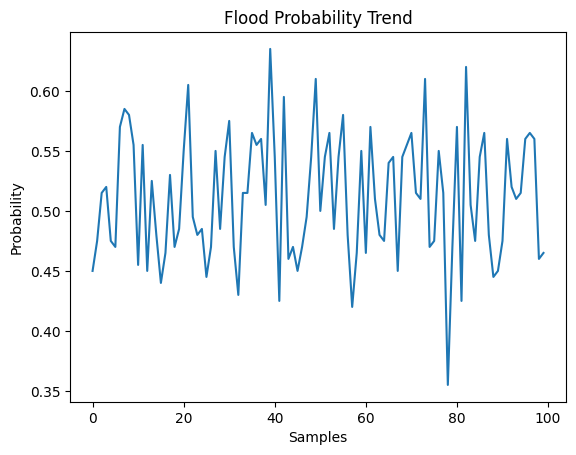

In [14]:
import matplotlib.pyplot as plt

plt.plot(df["FloodProbability"][:100])
plt.title("Flood Probability Trend")
plt.xlabel("Samples")
plt.ylabel("Probability")

plt.show()

#### Plot a graph for Monsoon Intensity


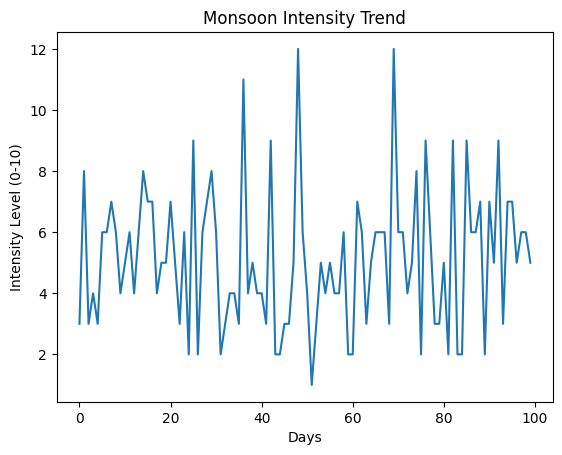

In [15]:
plt.plot(df["MonsoonIntensity"][:100])
plt.title("Monsoon Intensity Trend")
plt.xlabel("Days")
plt.ylabel("Intensity Level (0-10)")

plt.show()

### Step 13 - Create a StreamLit App
 
Points covered:
- Will use the trained model
- 20 Features from the Flood Dataset
- Trigger the alert in the UI

#### Define FEATURES variable

In [16]:
FEATURES = [
    'MonsoonIntensity',
    'TopographyDrainage',
    'RiverManagement',
    'Deforestation',
    'Urbanization',
    'ClimateChange',
    'DamsQuality',
    'Siltation',
    'AgriculturalPractices',
    'Encroachments',
    'IneffectiveDisasterPreparedness',
    'DrainageSystems',
    'CoastalVulnerability',
    'Landslides',
    'Watersheds',
    'DeterioratingInfrastructure',
    'PopulationScore',
    'WetlandLoss',
    'InadequatePlanning',
    'PoliticalFactors'
]

#### Create the Alert

In [17]:
import streamlit as st

def prediction_alert(input_data, threshold = 0.6):
    prediction = model.predict([input_data]) [0]

    # Check if prediction is higher than threshold
    alert = prediction >= threshold
    return prediction, alert

#### Create a Prediction Button with SMS + Email

In [19]:
# Collect input data drom user:
st.title("FLOW - Flood Prediction Dashboard")
st.subheader("Enter Environmental Parameters Below:")

# Define features (must match the model)
FEATURES = [
    'MonsoonIntensity',
    'TopographyDrainage',
    'RiverManagement',
    'Deforestation',
    'Urbanization',
    'ClimateChange',
    'DamsQuality',
    'Siltation',
    'AgriculturalPractices',
    'Encroachments',
    'IneffectiveDisasterPreparedness',
    'DrainageSystems',
    'CoastalVulnerability',
    'Landslides',
    'Watersheds',
    'DeterioratingInfrastructure',
    'PopulationScore',
    'WetlandLoss',
    'InadequatePlanning',
    'PoliticalFactors'
]

# Wrap inputs in a Streamlit Form
with st.form("Flood Form"):
    inputs = {}
    for feature in FEATURES:
        inputs[feature] = st.number_input(f"{feature}", min_value = 0.0, value = 0.0)
    submitted = st.form_submit_button("Save Inputs")

# When user clicks the button:
if st.button("Predict Flood Probability"):

    # Collect user input in the correct order:
    input_list = [inputs[col] for col in FEATURES]

    # Get prediction and alert status:
    threshold = 0.6
    probability, alert_flag = prediction_alert(input_list, threshold)

    # Show Prediction:
    st.write(f"### Predicted Flood Probability: {probability:.3f}")

    # If the probability is high, trigger alerts:
    if alert_flag:
        st.error("HIGH FLOOD RISK DETECTED!")

    # Send SMS Alert using Twiliio:
        if enable_sms and all([twilio_sid, twilio_token, twilio_from, sms_to]):
            try:
                from twilio.rest import Client
                client = Client(twilio_sid, twilio_token)
                message = f"Flood Alert! Probability: {probability:.2f}"
                client.messages.create(
                    body = message,
                    from_ = twilio_from,
                    to = sms_to
                )
                st.success("SMS Alert Sent!")
            except Exception as e:
                st.warning(f"SMS could not be sent: {e}")
        else:
            st.info("SMS Alert not set up or disabled.")

        # Send Email:
        if enable_email and all([smtp_host, smtp_user, smtp_pass, smtp_from, email_to]):
            try:
                import smtplib

                from email.mime.text import MIMEText
                email_text = f"""
                Flood Alert!
                Predicted Probability: {probability:.3f}
                Threshold: {threshold}
                """
                msg = MIMEText(email_text)
                msg["Subject"] = "Flood Alert"
                msg["From"] = smtp_from
                msg["To"] = email_to

                with smtplib.SMTP_SSL(smpt_host, 465) as server:
                    server.login(smtp_user, smtp_pass)
                    server.sendmail(smtp_from, [email_to], msg.as_string())

                st.success("Email Alert Sent!")
            except Exception as e:
                st.warning(f"Email could not be sent: {e}")
        else:
            st.info("Email Alert not set up or disabled.")

        # If probabilty is low:
    else:
        st.success("No immediate Flood Risk")

2025-10-31 14:39:54.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 14:39:54.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 14:39:54.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 14:39:54.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 14:39:54.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 14:39:54.944 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 14:39:54.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-31 14:39:54.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

### Step 14 - Run StreamLit APP
To run the app, type the following into the terminal/powershell:
 
streamlit run FLOW.py